# 04 - Business Insights & Hypothesis Testing
---
## Contexto

Este notebook dá continuidade à análise exploratória conduzida em `03_eda.ipynb`, com foco em **validação estatística das hipóteses levantadas** e **tradução dos resultados em recomendações estratégicas acionáveis**.

Cada hipótese segue o mesmo fluxo:
1. Definição formal de H0 e H1
2. Verificação de normalidade (Shapiro-Wilk + Q-Q Plot)
3. Escolha justificada do teste estatístico
4. Execução e interpretação do teste
5. Recomendação estratégica baseada no resultado

---

## Hipóteses Testadas

| # | Hipótese | Teste Utilizado |
|---|----------|-----------------|
| H1 | O ticket médio é igual entre as formas de pagamento | Kruskal-Wallis |
| H2 | O desconto não influencia o valor da compra | Correlação de Spearman |
| H3 | A receita não varia significativamente entre os meses | Kruskal-Wallis |
| H4 | O ticket médio de São Paulo é igual ao das demais cidades | Mann-Whitney U |

---

## Estrutura do Notebook

| Seção | Conteúdo |
|-------|----------|
| 01 | Imports e Configurações |
| 02 | Carregamento da Base |
| 03 | H1 — Ticket Médio por Forma de Pagamento |
| 04 | H2 — Impacto do Desconto no Valor da Compra |
| 05 | H3 — Sazonalidade Mensal |
| 06 | H4 — Ticket Médio de São Paulo vs Demais Cidades |
| 07 | Síntese Estratégica |

---
# 01 - Imports e Configurações

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scikit_posthocs as sp
import warnings

from scipy import stats
from scipy.stats import shapiro, kruskal, mannwhitneyu, spearmanr

warnings.filterwarnings('ignore')

# Estilo Visual
sns.set_theme(style="whitegrid", palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Formatação Numérica
def fmt_brl(valor):
    return f'R$ {valor:,.2f}'.replace(',', 'X').replace('.',',').replace('X', '.')

---
# 02 - Carregamento da Base

In [8]:
df = pd.read_csv('../data/processed/vendas_tratadas.csv')

df['Data da Venda'] = pd.to_datetime(df['Data da Venda'], format='mixed')

# Filtro Temporal - Exclui 2026 (datas inválidas identificadas na auditoria)
df = df[df['Data da Venda'].dt.year <= 2025]

# Feature Engineering Temporal
df['Ano']       = df['Data da Venda'].dt.year
df['Mes']       = df['Data da Venda'].dt.month
df['Trimestre'] = df['Data da Venda'].dt.quarter

mapa_mes = {
    1: 'Jan',
    2: 'Fev',
    3: 'Mar',
    4: 'Abr',
    5: 'Mai',
    6: 'Jun',
    7: 'Jul',
    8: 'Ago',
    9: 'Set',
    10: 'Out',
    11: 'Nov',
    12: 'Dez'
}

df['Nome_Mes'] = df['Mes'].map(mapa_mes)

print(f'Base Carregada: {df.shape[0]:,} registros | {df.shape[1]} colunas')
print(f'Período: {df['Data da Venda'].min().date()} a {df['Data da Venda'].max().date()}')

Base Carregada: 12,767 registros | 17 colunas
Período: 2023-01-01 a 2025-12-31


---
# 03 - H1: Ticket Médio por Forma de Pagamento

## Hipótese Formal

- **H0:** o ticket médio é igual entre todas as formas de pagamento
- **H1:** pelo menos uma forma de pagamento apresenta ticket médio significativamente diferente

**Nível de significância adotado:** α = 0,05

## 03.1 - Verificação de Normalidade

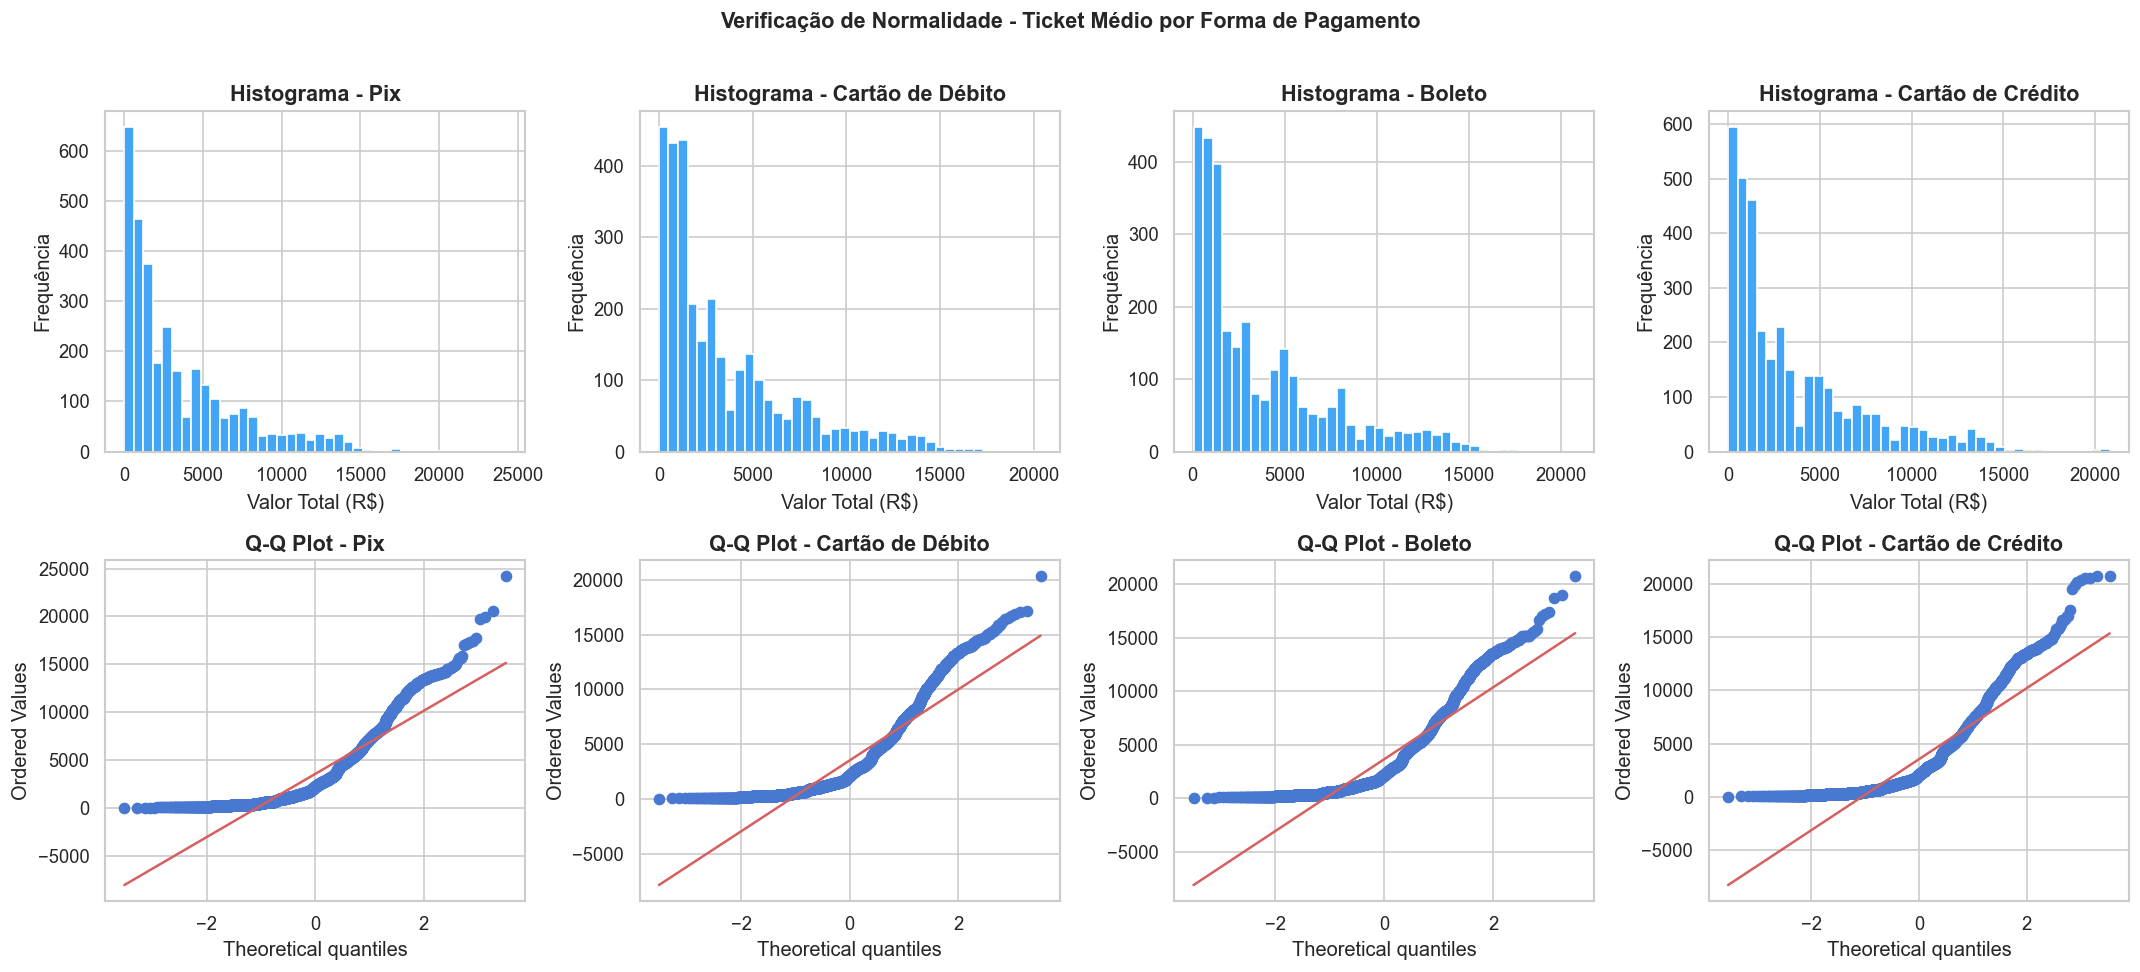

In [11]:
formas_pagamento = df['Forma de Pagamento'].unique()

fig, axes = plt.subplots(2, 4, figsize=(18,8))

for i, forma in enumerate(formas_pagamento):
    grupo = df[df['Forma de Pagamento'] == forma]['Valor_Total_Corrigido']

    # Histogramas
    axes[0, i].hist(grupo, bins=40, color='#42A5F5', edgecolor='white')
    axes[0, i].set_title(f'Histograma - {forma}')
    axes[0, i].set_xlabel('Valor Total (R$)')
    axes[0, i].set_ylabel('Frequência')

    ## Q-Q Plots
    stats.probplot(grupo, dist='norm', plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q Plot - {forma}')

plt.suptitle('Verificação de Normalidade - Ticket Médio por Forma de Pagamento',
             fontsize=13,
             fontweight='bold',
             y=1.01
            )
plt.tight_layout()
plt.show()

In [12]:
print('Shapiro-Wilk por Forma de Pagamento:')
print('-' * 45)

for forma in formas_pagamento:
    grupo = df[df['Forma de Pagamento'] == forma]['Valor_Total_Corrigido']
    stat, p = shapiro(grupo.sample(min(5000, len(grupo)), random_state=42))
    resultado = 'NÃO normal' if p < 0.05 else 'Normal'
    print(f'{forma:<20} | W={stat:.4f} | p={p:.4f} | {resultado}')

Shapiro-Wilk por Forma de Pagamento:
---------------------------------------------
Pix                  | W=0.8313 | p=0.0000 | NÃO normal
Cartão de Débito     | W=0.8311 | p=0.0000 | NÃO normal
Boleto               | W=0.8359 | p=0.0000 | NÃO normal
Cartão de Crédito    | W=0.8243 | p=0.0000 | NÃO normal


---
## 03.2 - Justificativa do Teste Estatístico

A verificação de normalidade indica que **nenhum grupo segue distribuição normal:**

| Forma de Pagamento | W | p-valor | Conclusão |
|--------------------|---|---------|-----------|
| Pix | 0.8313 | < 0,001 | NÃO normal |
| Cartão de Débito | 0.8311 | < 0,001 | NÃO normal |
| Boleto | 0.8359 | < 0,001 | NÃO normal |
| Cartão de Crédito | 0.8243 | < 0,001 | NÃO normal |

Essa conclusão é reforçada visualmente pelos **histogramas**, que mostram distribuição assimétrica à direita com cauda longa em todos os grupos, e pelos **Q-Q Plots**, onde os pontos se desviam sistematicamente da linha de referência nos extremos — padrão típico de distribuições não normais.

**Decisão:** como a premissa de normalidade não é atendida em nenhum grupo, a ANOVA não é apropriada. Utilizaremos o **Kruskal-Wallis**, equivalente não-paramétrico da ANOVA que não exige normalidade dos dados.

## 03.3 - Teste de Kruskal-Wallis

In [14]:
grupos_pagamento = [
    df[df['Forma de Pagamento'] == forma]['Valor_Total_Corrigido']
    for forma in formas_pagamento
]

stat, p = kruskal(*grupos_pagamento)

print('Kruskal-Wallis - Ticket Médio por Forma de Pagamento')
print('-' * 50)
print(f'H-statistic: {stat:.4f}')
print(f'p-valor    : {p:.4f}')
if p < 0.05:
    print('Resultado: REJEITA H0 - há diferença significativa entre pelo menos dois grupos.')
else:
    print('Resultado: NÃO rejeita H0 - não há diferença significativa entre os grupos')

Kruskal-Wallis - Ticket Médio por Forma de Pagamento
--------------------------------------------------
H-statistic: 6.0661
p-valor    : 0.1084
Resultado: NÃO rejeita H0 - não há diferença significativa entre os grupos


---
## 03.4 - Interpretação e Recomendação Estratégica

**Resultado do teste:**

| Estatística | Valor |
|-------------|-------|
| H-statistic | 6.0661 |
| p-valor | 0.1084 |
| Decisão | Não rejeita H0 |

Com p-valor de 0,1084 — superior ao nível de significância adotado (α = 0,05) — **não há evidência estatística de que o ticket médio difere entre as formas de pagamento.** A diferença observada na EDA (entre 3.521 e 3.667 reais) não é
suficientemente expressiva para ser considerada real — pode ser explicada por variação aleatória dos dados.

> **Nota:** como o Kruskal-Wallis não rejeitou H0, o post-hoc de Dunn não foi aplicado — ele só é necessário quando há diferença significativa entre os grupos para identificar quais pares diferem.

---

**Recomendação Estratégica**

A homogeneidade do ticket médio entre os meios de pagamento indica que a escolha do meio de pagamento não está associada ao perfil de gasto do cliente. Dessa forma:

- **Não há justificativa para ofertar descontos exclusivos por forma de pagamento** com o objetivo de aumentar o ticket médio — o impacto seria nulo.
- Estratégias de incentivo a meios específicos (como cashback em Pix) devem ser avaliadas por outros critérios, como **custo de transação** ou **velocidade de liquidação**, e não pelo valor da compra.
- O esforço comercial para aumentar ticket médio deve ser direcionado a outras variáveis — como **mix de produtos**, **cross-sell** ou **faixas de desconto por volume** — que demonstraram maior relação com o valor da compra na análise de correlações.

---
# 04 - H2: Impacto do Desconto no Valor da Compra

## Hipótese Formal

- **H0:** não há correlação entre o desconto aplicado e o valor da compra
- **H1:** existe correlação significativa entre o desconto aplicado e o valor da compra

**Nível de significância adotado:** α = 0,05

## 04.1 - Verificação de Normalidade

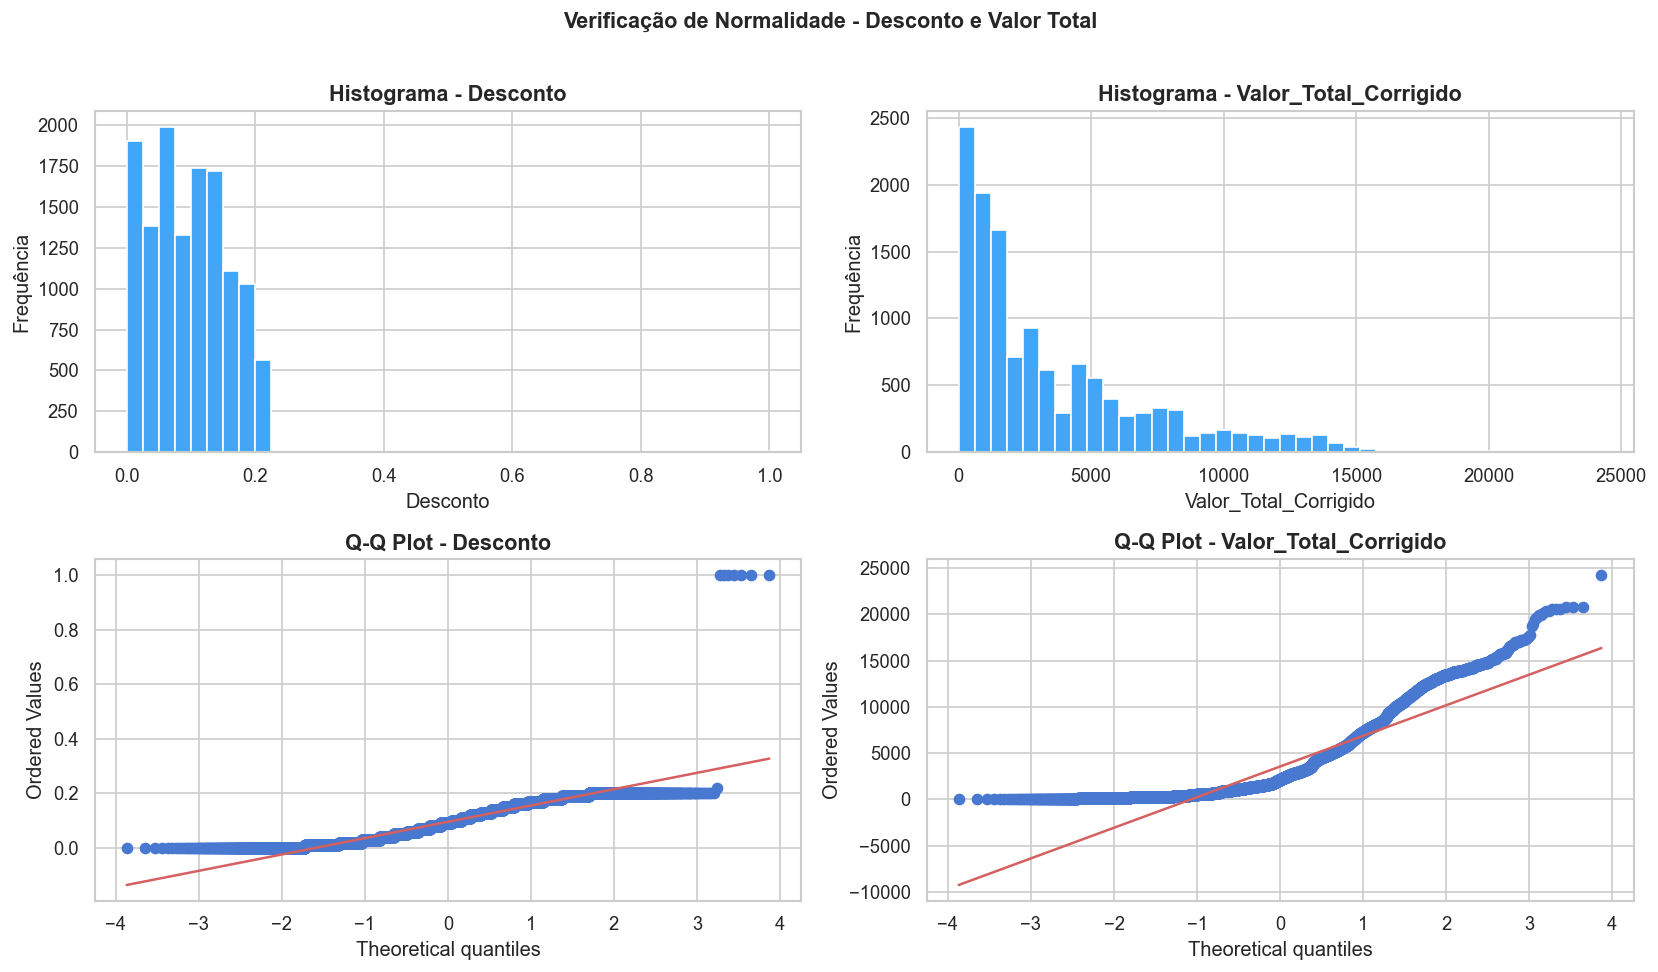

In [16]:
variaveis = {
    'Desconto': df['Desconto'],
    'Valor_Total_Corrigido': df['Valor_Total_Corrigido']
}

fig, axes = plt.subplots(2, 2, figsize=(14,8))

for i, (nome, serie) in enumerate(variaveis.items()):
    # Histograma
    axes[0, i].hist(serie, bins=40, color='#42A5F5', edgecolor='white')
    axes[0, i].set_title(f'Histograma - {nome}')
    axes[0, i].set_xlabel(nome)
    axes[0, i].set_ylabel('Frequência')

    # Q-Q Plot
    stats.probplot(serie, dist='norm', plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q Plot - {nome}')

plt.suptitle('Verificação de Normalidade - Desconto e Valor Total',
             fontsize=13,
             fontweight='bold',
             y=1.01
            )
plt.tight_layout()
plt.show()

In [18]:
print('Shapiro-Wilk:')
print('-' * 45)

for nome, serie in variaveis.items():
    stat, p = shapiro(serie.sample(min(5000, len(serie)), random_state=42))
    resultado = 'NÃO normal' if p < 0.05 else 'Normal'
    print(f'{nome:<25} | W={stat:.4f} | p={p:.4f} | {resultado}')

Shapiro-Wilk:
---------------------------------------------
Desconto                  | W=0.9079 | p=0.0000 | NÃO normal
Valor_Total_Corrigido     | W=0.8315 | p=0.0000 | NÃO normal


---
## 04.2 - Justificativa do Teste Estatístico

| Variável | W | p-valor | Conclusão |
|----------|---|---------|-----------|
| Desconto | 0.9079 | < 0,001 | NÃO normal |
| Valor_Total_Corrigido | 0.8315 | < 0,001 | NÃO normal |

Os histogramas confirmam o resultado do Shapiro-Wilk: o **Desconto** apresenta
distribuição assimétrica concentrada entre 0 e 0,20, enquanto o
**Valor_Total_Corrigido** apresenta cauda longa à direita — ambos afastados
de uma distribuição normal.

O Q-Q Plot do Desconto revela ainda um ponto de inflexão abrupto no extremo
superior, correspondente à única transação com desconto acima de 20% identificada
na EDA.

**Decisão:** como nenhuma das duas variáveis segue distribuição normal, a
correlação de Pearson não é apropriada. Utilizaremos a **Correlação de Spearman**,
que mede a relação monotônica entre as variáveis sem exigir normalidade.

## 04.3 - Correlação de Spearman

In [56]:
corr, p = spearmanr(df['Desconto'], df['Valor_Total_Corrigido'])

print('Correlação de Spearman - Desconto * Valor Total')
print('-' * 50)
print(f'Coeficiente : {corr:.4f}')
print(f'p-valor     : {p:.4f}')
print()
if p < 0.05:
    direcao = 'positiva' if corr > 0 else 'negativa'
    intensidade = 'forte' if abs(corr) > 0.7 else 'moderada' if abs(corr) > 0.4 else 'fraca'
    print(f'Resultado: REJEITA H0 — correlação {direcao} e {intensidade} (ρ={corr:.4f})')
else:
    print('Resultado: NÃO rejeita H0 - não há correlação significativa.')


Correlação de Spearman - Desconto * Valor Total
--------------------------------------------------
Coeficiente : -0.0429
p-valor     : 0.0000

Resultado: REJEITA H0 — correlação negativa e fraca (ρ=-0.0429)


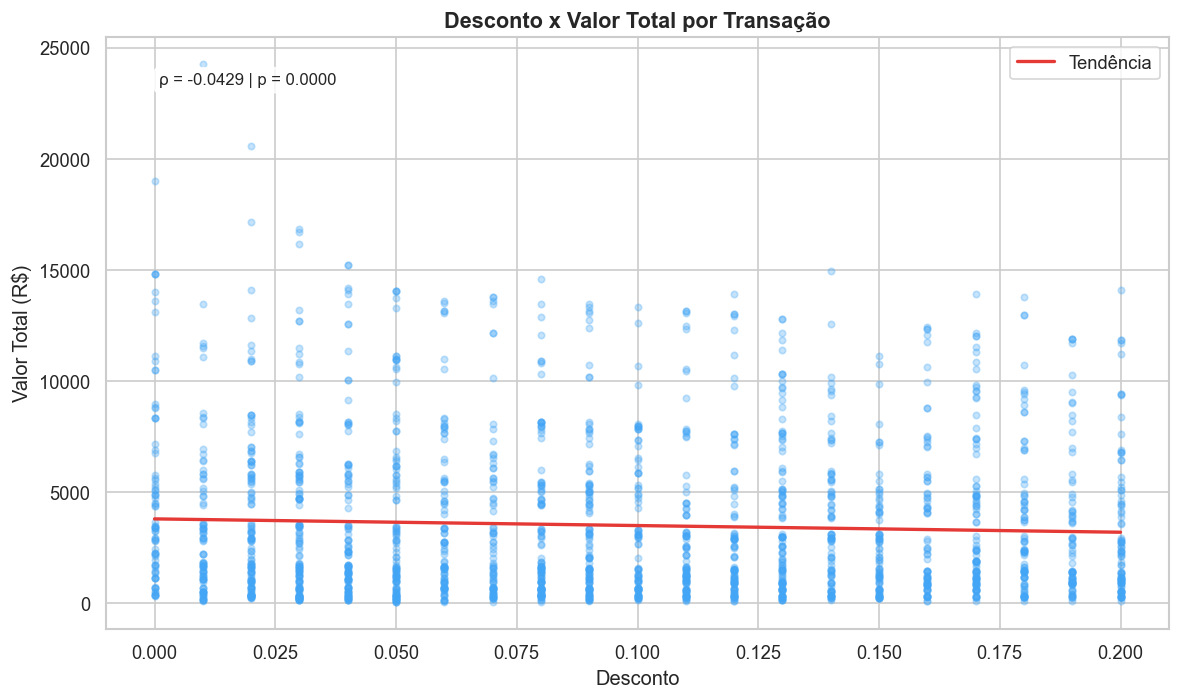

In [59]:
fig, ax = plt.subplots(figsize=(10,6))

# Filtra outlier de desconto = 1.0 apenas para a visualização
amostra = df[df['Desconto'] < 0.25].sample(2000, random_state=42)

ax.scatter(amostra['Desconto'], amostra['Valor_Total_Corrigido'],
           alpha=0.3,
           color='#42A5F5',
           s=15
          )

m, b = np.polyfit(amostra['Desconto'], amostra['Valor_Total_Corrigido'], 1)
x_line = np.linspace(amostra['Desconto'].min(), amostra['Desconto'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#E53935', linewidth=2, label='Tendência')

ax.set_title('Desconto x Valor Total por Transação')
ax.set_xlabel('Desconto')
ax.set_ylabel('Valor Total (R$)')
ax.legend()
ax.text(0.05, 0.92, f'ρ = {corr:.4f} | p = {p:.4f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

---
## 04.4 - Interpretação e Recomendação Estratégica

**Resultado do teste:**

| Estatística | Valor |
|-------------|-------|
| Coeficiente de Spearman (ρ) | -0.0429 |
| p-valor | < 0,001 |
| Decisão | Rejeita H0 |

O teste rejeita H0 — existe correlação estatisticamente significativa entre desconto e valor da compra. No entanto, o coeficiente de Spearman de **-0.0429** revela que essa correlação é **negativa e extremamente fraca**, explicando menos
de 0,2% da variação do valor total (ρ² ≈ 0,0018).

O scatter plot confirma visualmente: a linha de tendência é praticamente plana, e os pontos estão amplamente dispersos em todas as faixas de desconto — sem nenhum padrão estruturado entre as duas variáveis.

> **Nota sobre significância estatística vs relevância prática:** p-valor baixo não significa correlação forte — com 12.767 registros, o teste tem poder estatístico suficiente para detectar correlações minúsculas que não têm relevância prática. O coeficiente ρ = -0.0429 é estatisticamente significativo mas operacionalmente irrelevante.

---

**Recomendação Estratégica**

A ausência de correlação prática entre desconto e valor da compra indica que a política de descontos atual é **indiferenciada** — descontos maiores não estão sendo direcionados a transações de maior valor nem gerando compras maiores:

- **Revisar a política de descontos:** atualmente os descontos variam entre 0% e 20% de forma aparentemente aleatória em relação ao valor da compra. Uma política baseada em **desconto progressivo por valor de compra** poderia incentivar o aumento do ticket médio — por exemplo, 5% para compras acima de 5.000 reais e 10% para compras acima de 10.000 reais.
- **Avaliar o custo dos descontos:** como os descontos não estão associados a compras maiores, cada desconto concedido representa redução direta de margem sem contrapartida em volume ou valor — o impacto financeiro dessa política merece ser quantificado.

---
# 05 - H3: Sazonalidade Mensal

## Hipótese Formal

- **H0:** a receita mensal não varia significativamente entre os meses do ano
- **H1:** pelo menos um mês apresenta receita significativamente diferente dos demais

**Nível de significância adotado:** α = 0,05

## 05.1 - Verificação de Normalidade

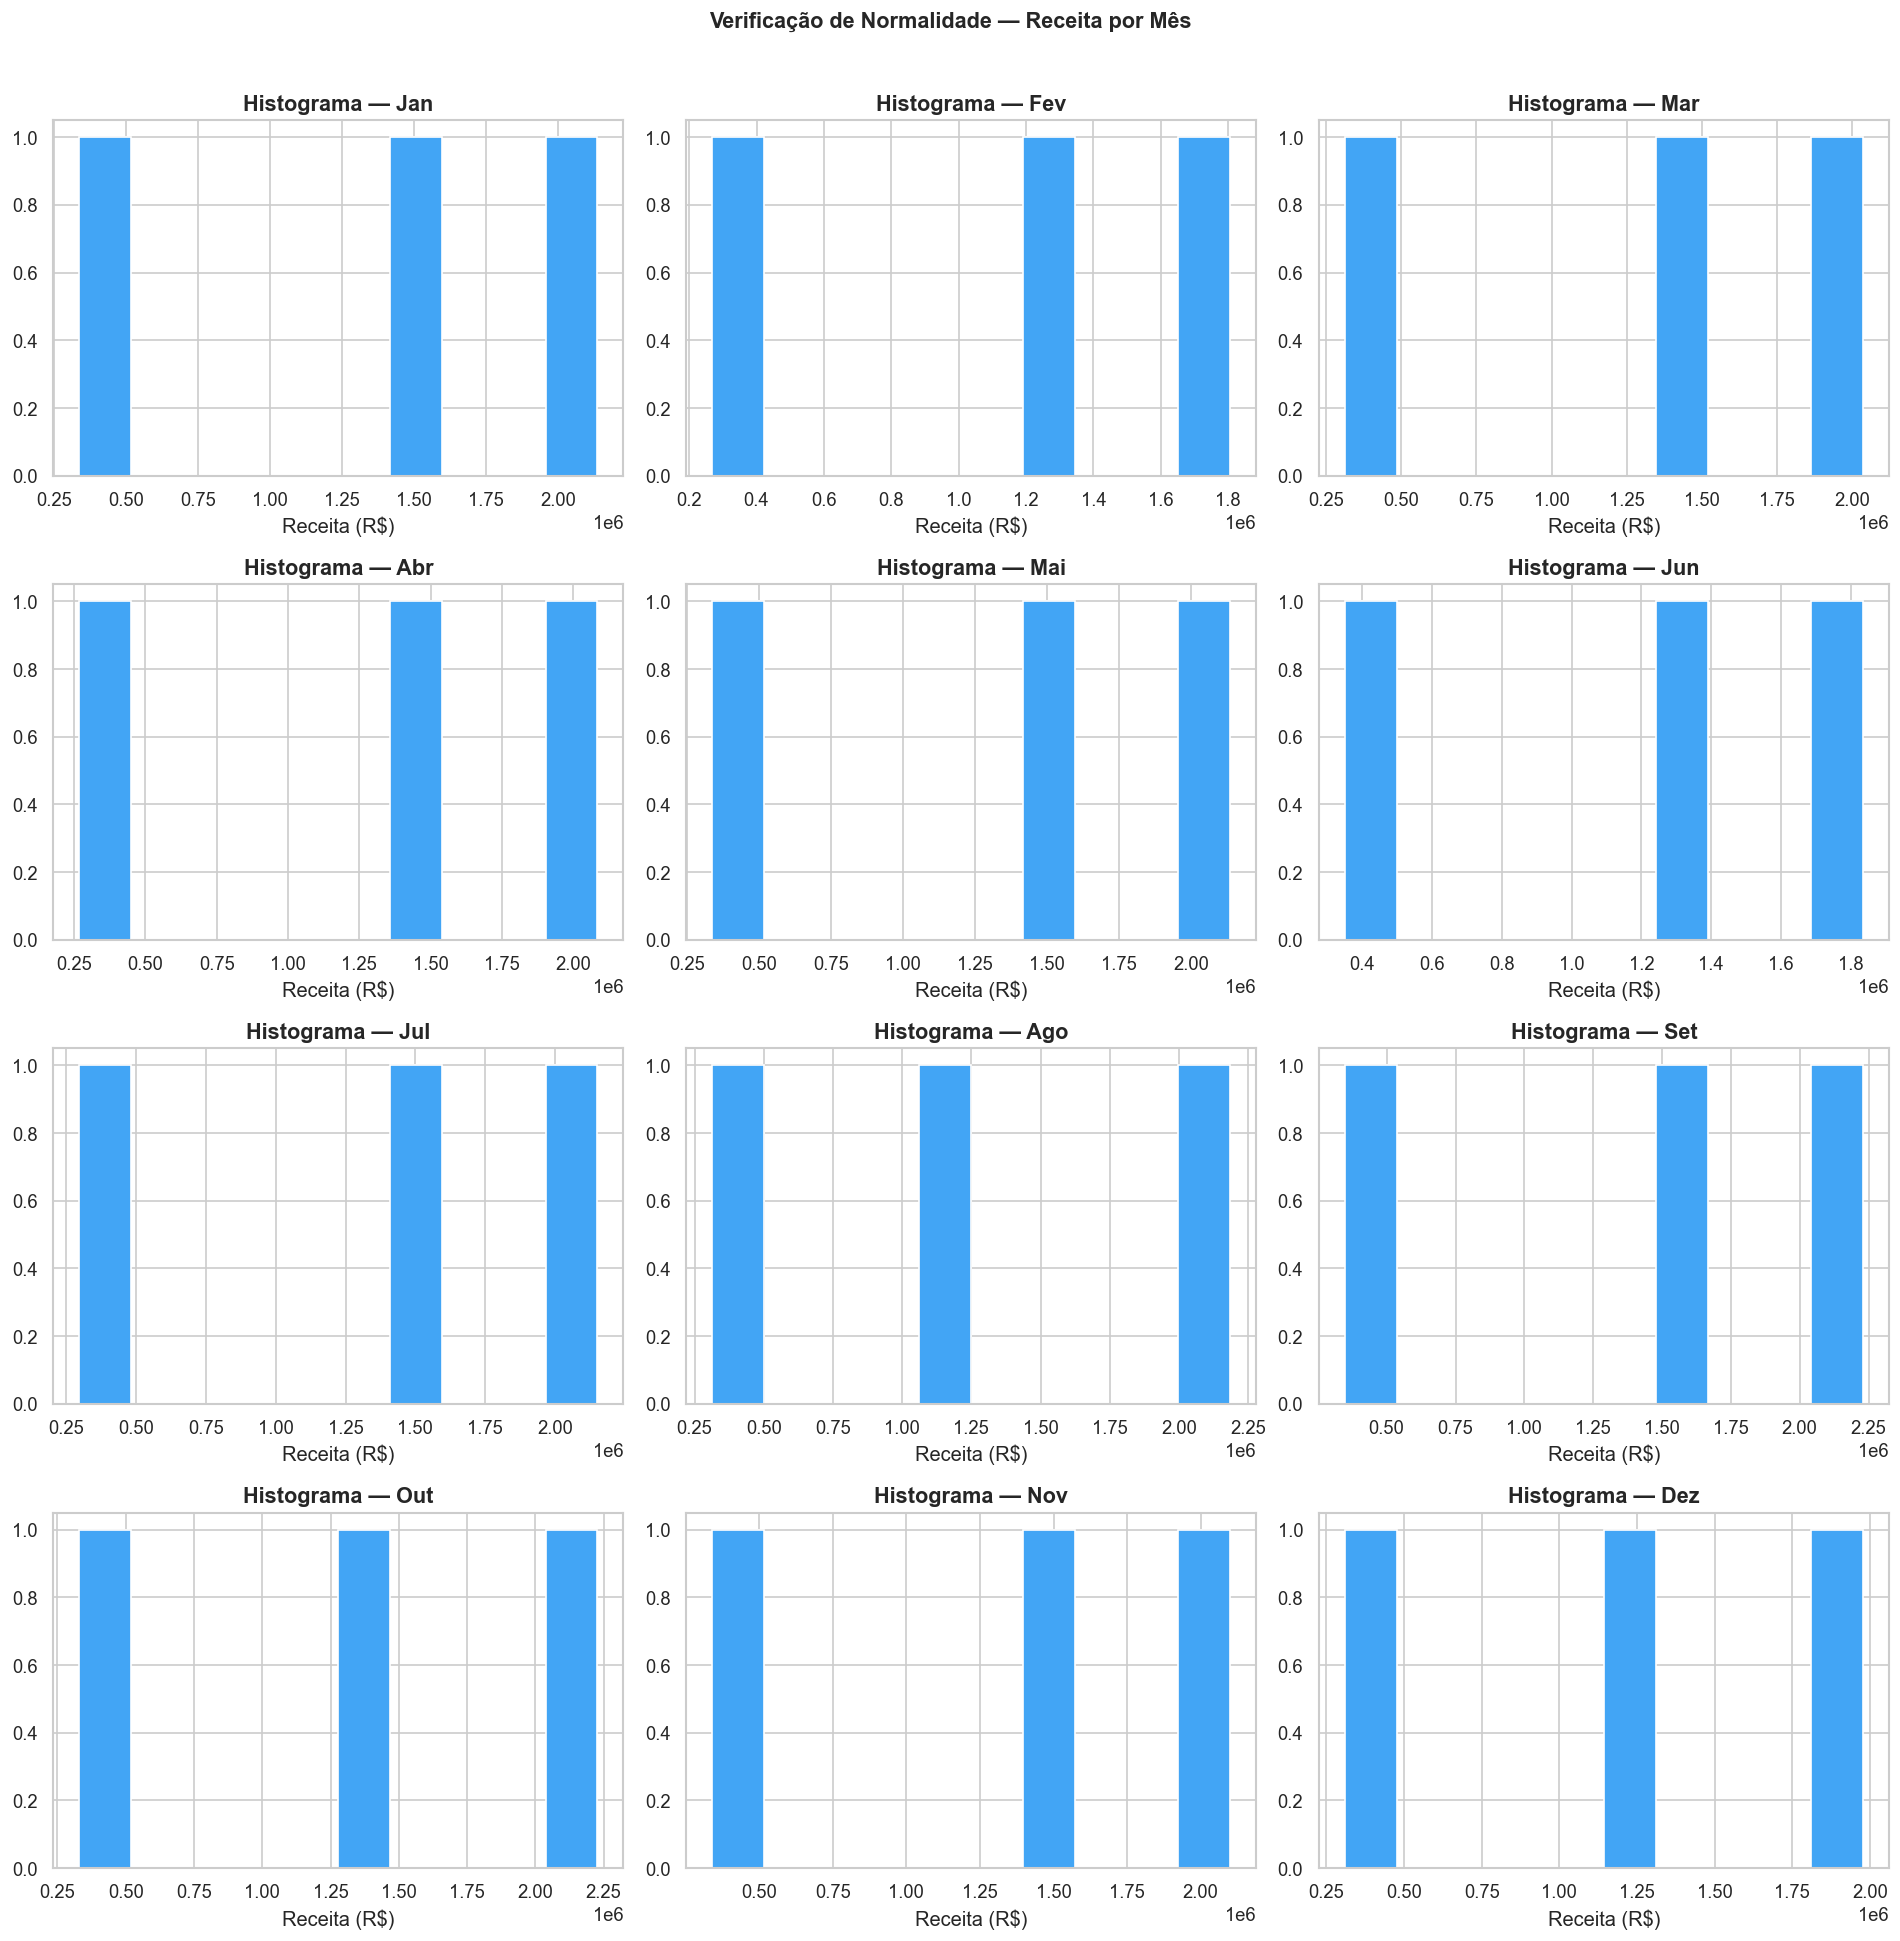

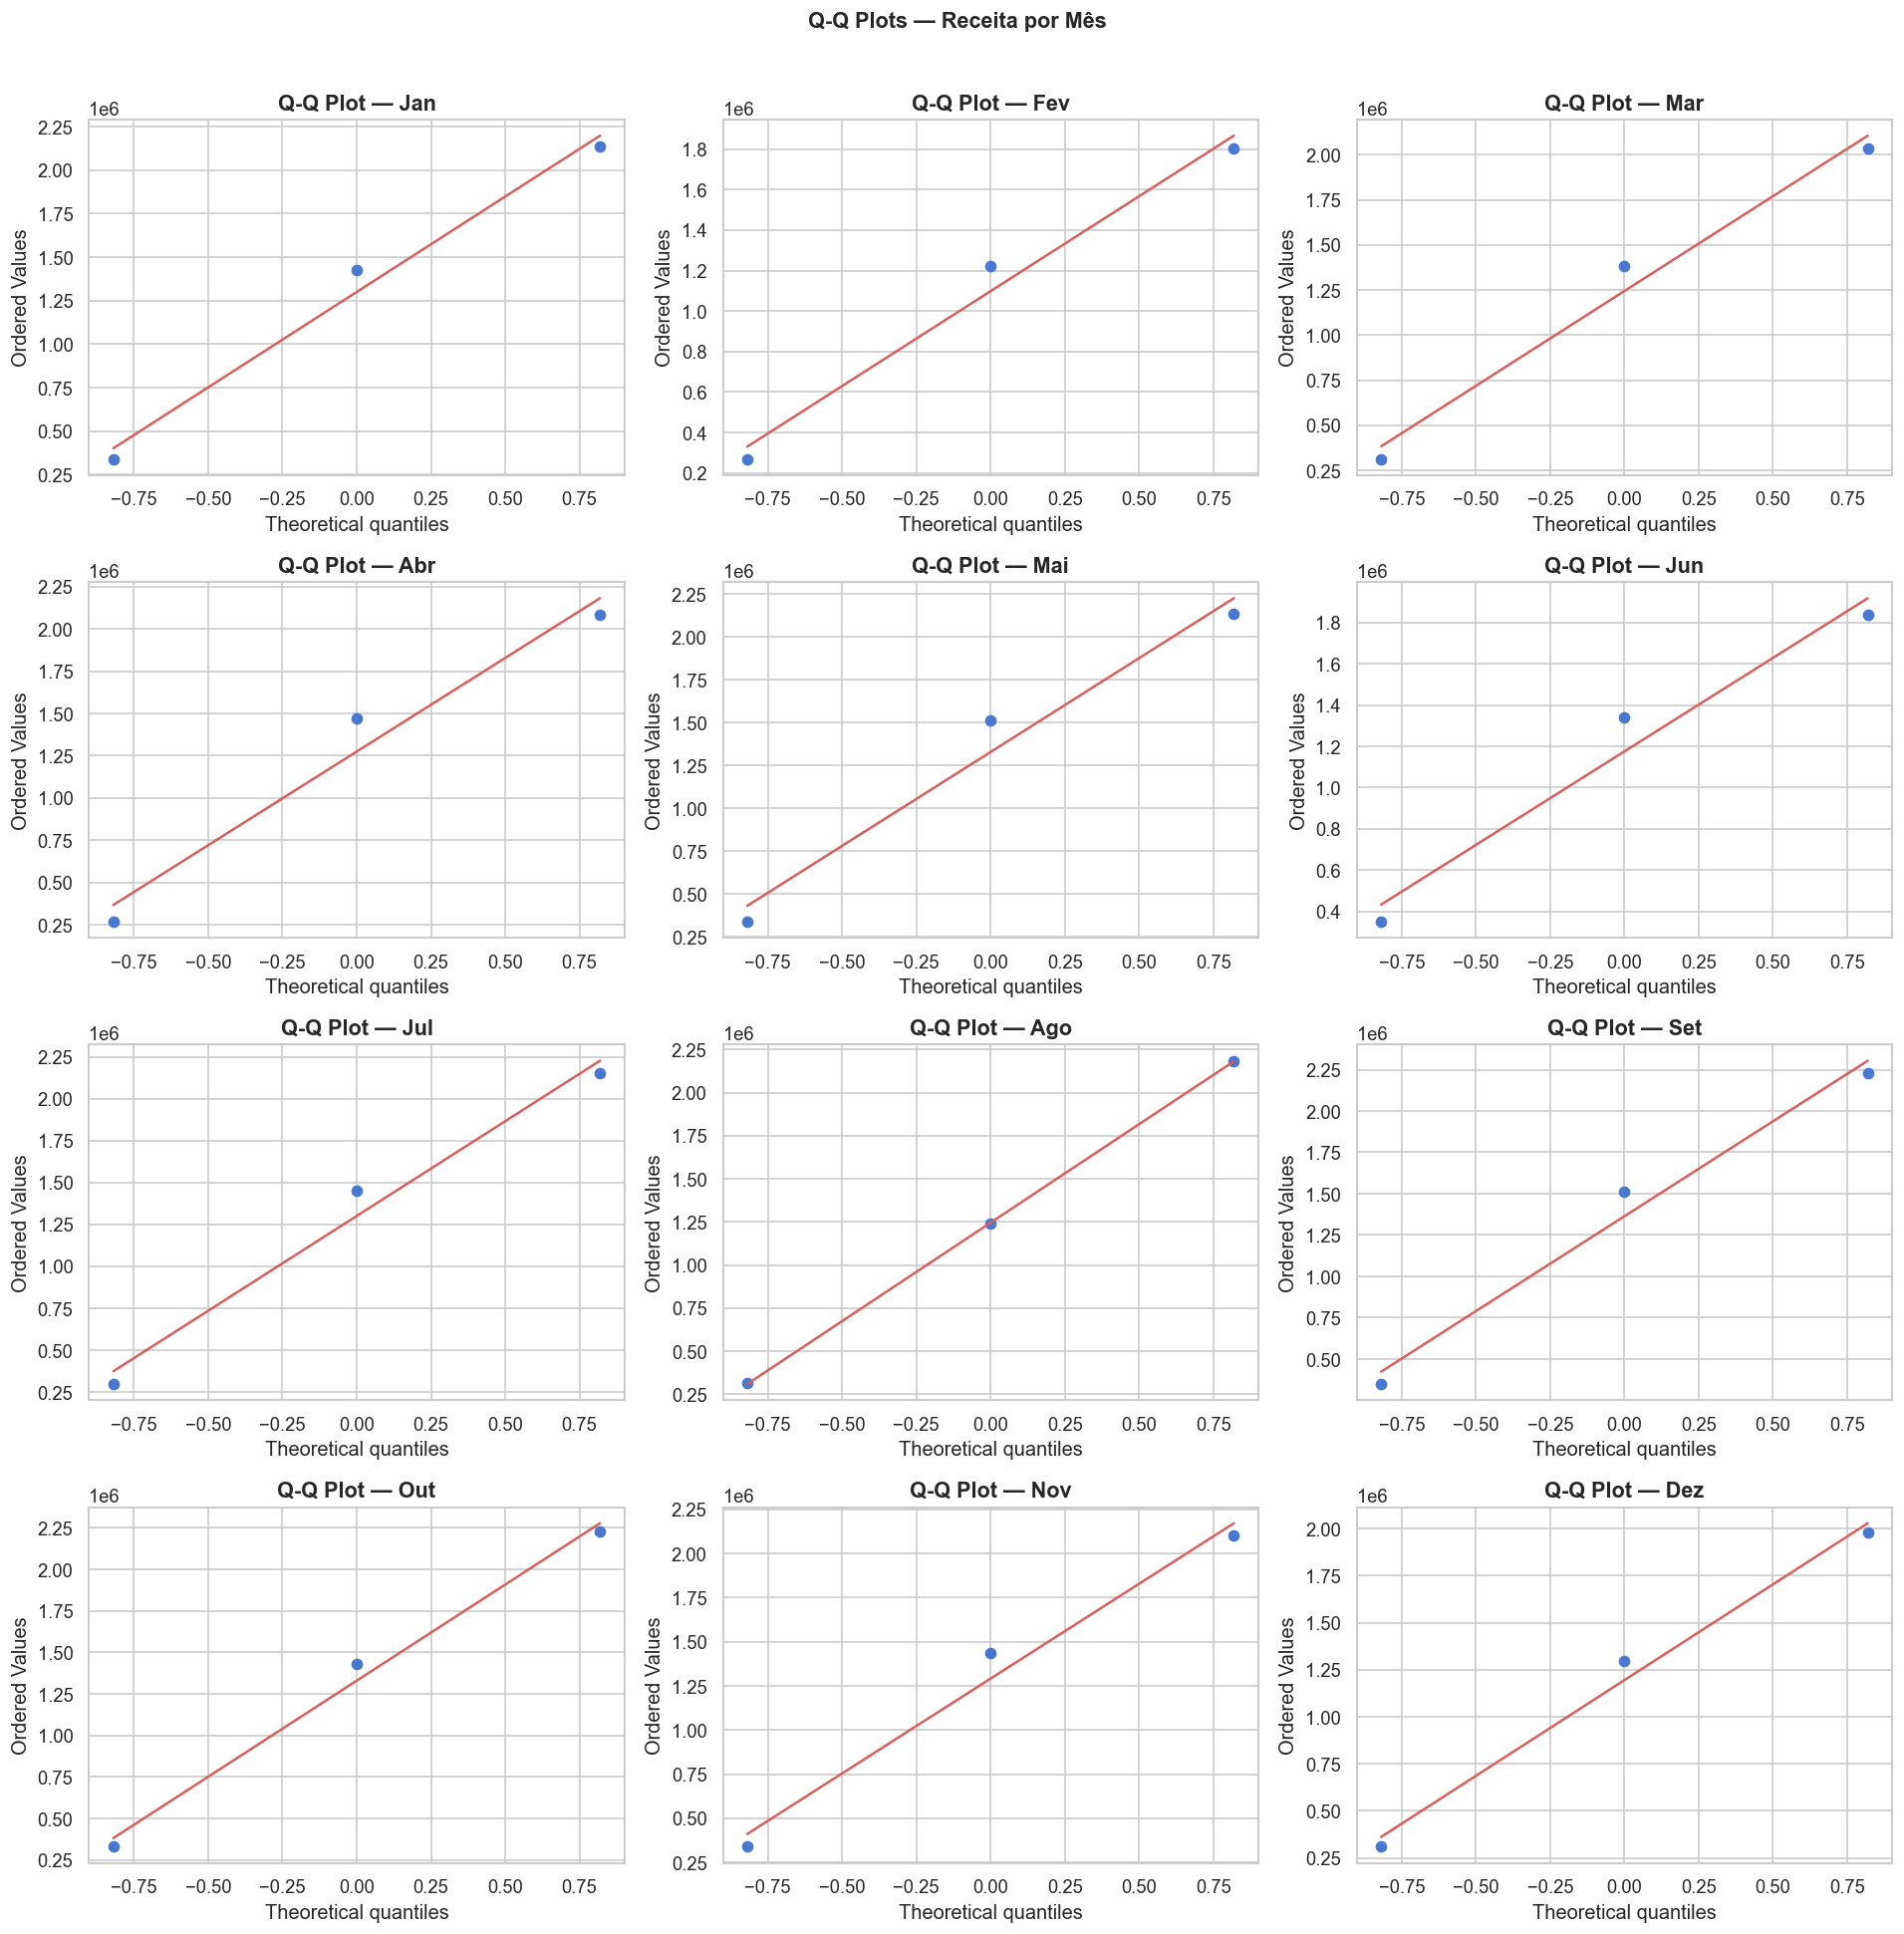

In [64]:
# Receita agregada por Ano-Mês para ter uma observação por período
receita_mensal = (
    df.groupby(['Ano', 'Mes'])['Valor_Total_Corrigido']
    .sum()
    .reset_index()
)

meses = sorted(receita_mensal['Mes'].unique())

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, mes in enumerate(meses):
    grupo = receita_mensal[receita_mensal['Mes'] == mes]['Valor_Total_Corrigido']
    nome = df[df['Mes'] == mes]['Nome_Mes'].iloc[0]
    
    axes[i].hist(grupo, bins=10, color='#42A5F5', edgecolor='white')
    axes[i].set_title(f'Histograma — {nome}')
    axes[i].set_xlabel('Receita (R$)')

plt.suptitle('Verificação de Normalidade — Receita por Mês',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, mes in enumerate(meses):
    grupo = receita_mensal[receita_mensal['Mes'] == mes]['Valor_Total_Corrigido']
    nome = df[df['Mes'] == mes]['Nome_Mes'].iloc[0]
    
    stats.probplot(grupo, dist='norm', plot=axes[i])
    axes[i].set_title(f'Q-Q Plot — {nome}')

plt.suptitle('Q-Q Plots — Receita por Mês',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [63]:
print('Shapiro-Wilk por Mês:')
print('-' * 45)

for mes in meses:
    grupo = receita_mensal[receita_mensal['Mes'] == mes]['Valor_Total_Corrigido']
    nome = mapa_mes[mes]

    if len(grupo) >= 3:
        stat, p = shapiro(grupo)
        resultado = 'NÃO normal' if p < 0.05 else 'Normal'
    else:
        stat, p, resultado = None, None, 'Amostra insuficiente'

    print(f'{nome:<5} | n={len(grupo)} | W={stat:.4f} | p={p:.4f} | {resultado}')

Shapiro-Wilk por Mês:
---------------------------------------------
Jan   | n=3 | W=0.9860 | p=0.7736 | Normal
Fev   | n=3 | W=0.9814 | p=0.7388 | Normal
Mar   | n=3 | W=0.9804 | p=0.7316 | Normal
Abr   | n=3 | W=0.9661 | p=0.6464 | Normal
Mai   | n=3 | W=0.9697 | p=0.6656 | Normal
Jun   | n=3 | W=0.9645 | p=0.6378 | Normal
Jul   | n=3 | W=0.9800 | p=0.7287 | Normal
Ago   | n=3 | W=1.0000 | p=0.9874 | Normal
Set   | n=3 | W=0.9813 | p=0.7384 | Normal
Out   | n=3 | W=0.9913 | p=0.8221 | Normal
Nov   | n=3 | W=0.9806 | p=0.7334 | Normal
Dez   | n=3 | W=0.9887 | p=0.7968 | Normal


---
## 05.2 - Justificativa do Teste Estatístico

| Mês | n | W | p-valor | Conclusão |
|-----|---|---|---------|-----------|
| Jan | 3 | 0.9860 | 0.7736 | Normal |
| Fev | 3 | 0.9814 | 0.7388 | Normal |
| Mar | 3 | 0.9804 | 0.7316 | Normal |
| Abr | 3 | 0.9661 | 0.6464 | Normal |
| Mai | 3 | 0.9697 | 0.6656 | Normal |
| Jun | 3 | 0.9645 | 0.6378 | Normal |
| Jul | 3 | 0.9800 | 0.7287 | Normal |
| Ago | 3 | 1.0000 | 0.9874 | Normal |
| Set | 3 | 0.9813 | 0.7384 | Normal |
| Out | 3 | 0.9913 | 0.8221 | Normal |
| Nov | 3 | 0.9806 | 0.7334 | Normal |
| Dez | 3 | 0.9887 | 0.7968 | Normal |

O Shapiro-Wilk indica normalidade em todos os meses, porém esse resultado deve ser interpretado com cautela: cada mês possui apenas **3 observações** (uma por ano), o que é insuficiente para o teste ter poder estatístico adequado — com amostras tão pequenas, o teste dificilmente rejeita H0 independentemente da distribuição real.

Os histogramas confirmam essa limitação: com apenas 3 barras cada, não é possível inferir a forma da distribuição visualmente. Os Q-Q Plots mostram os pontos razoavelmente alinhados com a linha de referência, mas também sem poder discriminativo com n=3.

**Decisão:** dado o tamanho amostral reduzido e a consequente limitação dos testes de normalidade, optamos pelo **Kruskal-Wallis** por ser mais robusto e conservador — não exige normalidade e funciona bem com amostras pequenas. Essa escolha é mais segura do que assumir normalidade com base em um teste sem poder estatístico suficiente.

## 05.3 - Teste de Kruskal-Wallis

In [65]:
grupos_mes = [
    receita_mensal[receita_mensal['Mes'] == mes]['Valor_Total_Corrigido']
    for mes in meses
]

stat, p = kruskal(*grupos_mes)

print('Kruskal-Wallis — Receita por Mês')
print('-' * 50)
print(f'H-statistic : {stat:.4f}')
print(f'p-valor     : {p:.4f}')
print()
if p < 0.05:
    print('Resultado: REJEITA H0 — há diferença significativa entre pelo menos dois meses.')
else:
    print('Resultado: NÃO rejeita H0 — não há diferença significativa entre os meses.')

Kruskal-Wallis — Receita por Mês
--------------------------------------------------
H-statistic : 2.2553
p-valor     : 0.9974

Resultado: NÃO rejeita H0 — não há diferença significativa entre os meses.


---
## 05.4 - Interpretação e Recomendação Estratégica

**Resultado do teste:**

| Estatística | Valor |
|-------------|-------|
| H-statistic | 2.2553 |
| p-valor | 0.9974 |
| Decisão | Não rejeita H0 |

Com p-valor de 0,9974 — muito acima do nível de significância adotado (α = 0,05) — **não há evidência estatística de que a receita varia significativamente entre os meses do ano.** As diferenças observadas na EDA entre meses como Fevereiro e Setembro não são suficientemente consistentes para ser consideradas reais do ponto de vista estatístico.

> ⚠️ **Limitação importante:** cada mês possui apenas 3 observações (2023, 2024 e 2025), o que reduz significativamente o poder estatístico do teste. Com n=3 por grupo, tanto o Shapiro-Wilk quanto o Kruskal-Wallis têm dificuldade em detectar diferenças reais. Uma conclusão mais robusta exigiria pelo menos 5 anos de dados — o que reforça a ressalva já documentada na EDA sobre a limitação da base para análise de sazonalidade.

> **Nota:** como o Kruskal-Wallis não rejeitou H0, o post-hoc de Dunn não foi aplicado.

---

**Recomendação Estratégica**

Apesar de o teste não confirmar sazonalidade estatisticamente significativa, os padrões identificados na EDA — Fevereiro consistentemente mais fraco, segundo semestre de 2025 mais forte — ainda merecem atenção operacional:

- **Não tomar decisões estruturais de estoque ou campanha baseadas em sazonalidade** enquanto a base não tiver mais anos de histórico — o risco de agir sobre um padrão que pode ser ruído é real.
- **Monitorar ativamente Fevereiro e Dezembro** nos próximos anos para verificar se o padrão de menor receita se confirma — se persistir em 2026 e 2027, a evidência será mais sólida para justificar ações sazonais.
- **Reavaliar essa hipótese com 5+ anos de dados**, quando o teste terá poder estatístico adequado para uma conclusão mais confiável.

---
# 06 - H4: Ticket Médio de São Paulo vs Demais Cidades

## Hipótese Formal

- **H0:** o ticket médio de São Paulo é igual ao das demais cidades
- **H1:** o ticket médio de São Paulo é significativamente diferente do das demais cidades

**Nível de significância adotado:** α = 0,05

## 06.1 - Verificação de Normalidade

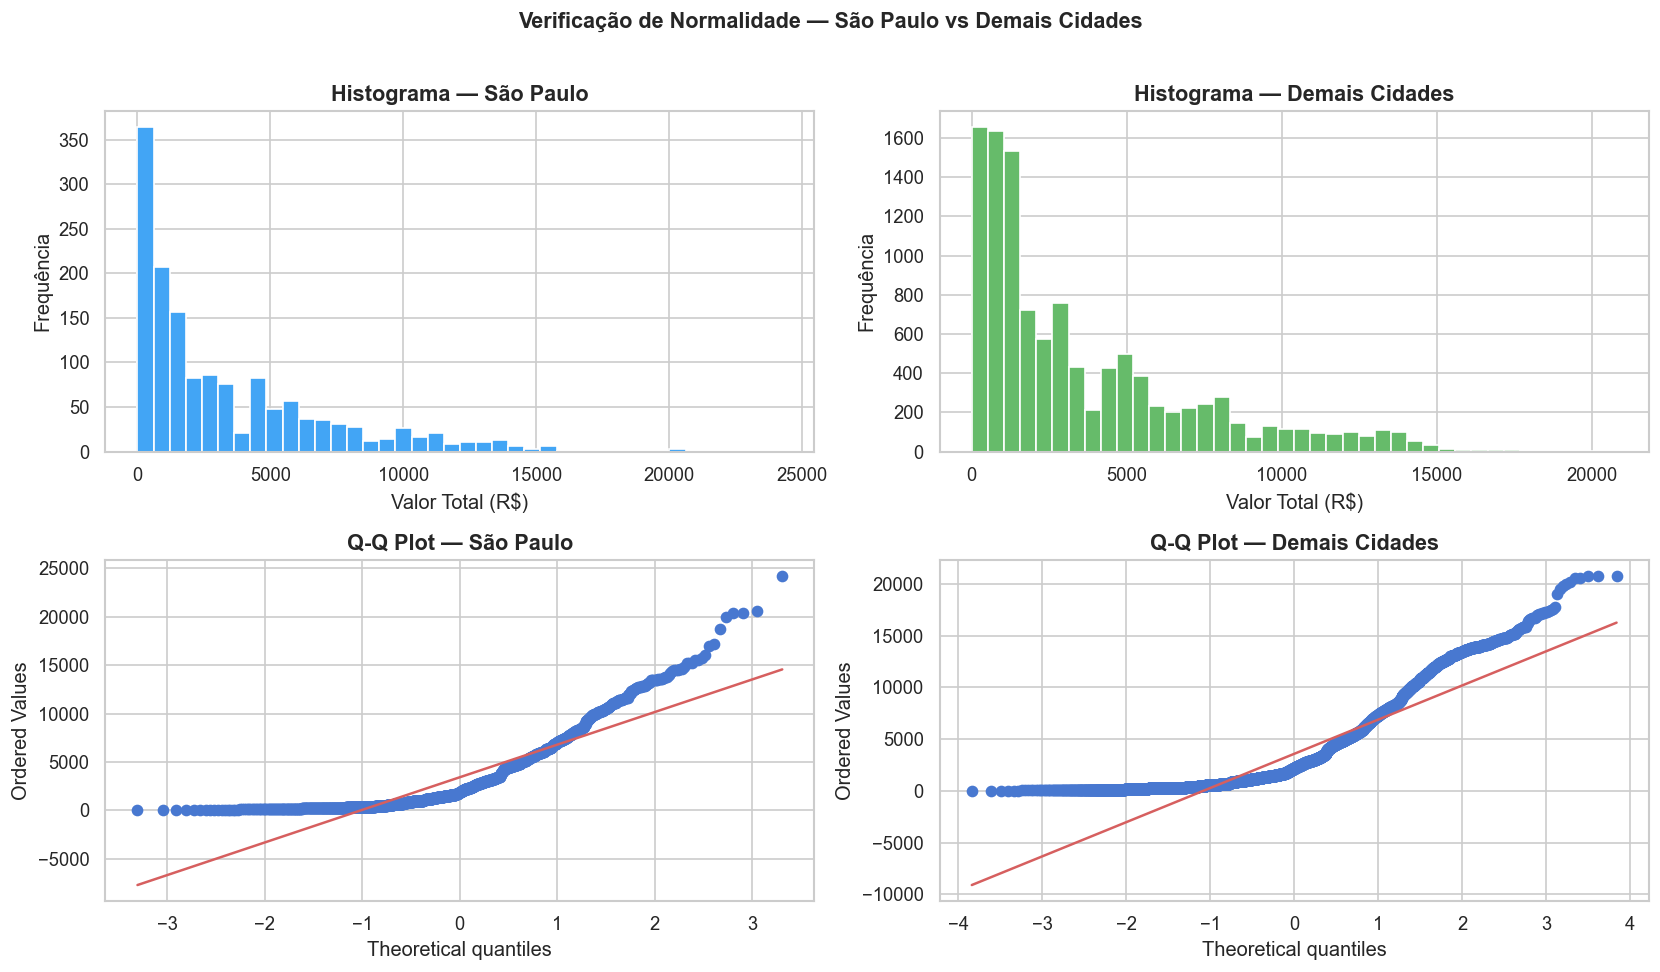

In [66]:
sp = df[df['Localização'] == 'São Paulo']['Valor_Total_Corrigido']
demais = df[df['Localização'] != 'São Paulo']['Valor_Total_Corrigido']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Histogramas
axes[0, 0].hist(sp, bins=40, color='#42A5F5', edgecolor='white')
axes[0, 0].set_title('Histograma — São Paulo')
axes[0, 0].set_xlabel('Valor Total (R$)')
axes[0, 0].set_ylabel('Frequência')

axes[0, 1].hist(demais, bins=40, color='#66BB6A', edgecolor='white')
axes[0, 1].set_title('Histograma — Demais Cidades')
axes[0, 1].set_xlabel('Valor Total (R$)')
axes[0, 1].set_ylabel('Frequência')

# Q-Q Plots
stats.probplot(sp, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot — São Paulo')

stats.probplot(demais, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot — Demais Cidades')

plt.suptitle('Verificação de Normalidade — São Paulo vs Demais Cidades',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [67]:
print('Shapiro-Wilk:')
print('-' * 50)

for nome, grupo in [('São Paulo', sp), ('Demais Cidades', demais)]:
    stat, p = shapiro(grupo.sample(min(5000, len(grupo)), random_state=42))
    resultado = 'NÃO normal' if p < 0.05 else 'Normal'
    print(f'{nome:<20} | n={len(grupo):>5} | W={stat:.4f} | p={p:.4f} | {resultado}')

Shapiro-Wilk:
--------------------------------------------------
São Paulo            | n= 1468 | W=0.8151 | p=0.0000 | NÃO normal
Demais Cidades       | n=11299 | W=0.8294 | p=0.0000 | NÃO normal


---
## 06.2 - Justificativa do Teste Estatístico

| Grupo | n | W | p-valor | Conclusão |
|-------|---|---|---------|-----------|
| São Paulo | 1.468 | 0.8151 | < 0,001 | NÃO normal |
| Demais Cidades | 11.299 | 0.8294 | < 0,001 | NÃO normal |

Ambos os grupos apresentam distribuição assimétrica à direita com cauda longa, confirmada pelos histogramas e pelos Q-Q Plots — onde os pontos se desviam sistematicamente da linha de referência nos extremos superiores, padrão idêntico ao observado nas hipóteses anteriores.

**Decisão:** como nenhum dos grupos segue distribuição normal, utilizaremos o **Mann-Whitney U** — equivalente não-paramétrico do teste t para duas amostras independentes.

## 06.3 - Teste de Mann-Whitney U

In [69]:
stat, p = mannwhitneyu(sp, demais, alternative='two-sided')

print('Mann-Whitney U - São Paulo vs Demais Cidades')
print('-' * 50)
print(f'U-statistic : {stat:.4f}')
print(f'p-valor     : {p:.4f}')
print()
print(f'Ticket médio - São Paulo   : {fmt_brl(sp.mean())}')
print(f'Ticket médio - Demais      : {fmt_brl(demais.mean())}')
print(f'Diferença                  : {fmt_brl(sp.mean() - demais.mean())}')
print()
if p < 0.05:
    print('Resultado: REJEITA H0 - diferença significativa entre São Paulo e demais cidades.')
else:
    print('Resultado: NÃO rejeita H0 - não há diferença significativa.')

Mann-Whitney U - São Paulo vs Demais Cidades
--------------------------------------------------
U-statistic : 7787712.0000
p-valor     : 0.0001

Ticket médio - São Paulo   : R$ 3.420,22
Ticket médio - Demais      : R$ 3.576,60
Diferença                  : R$ -156,39

Resultado: REJEITA H0 - diferença significativa entre São Paulo e demais cidades.


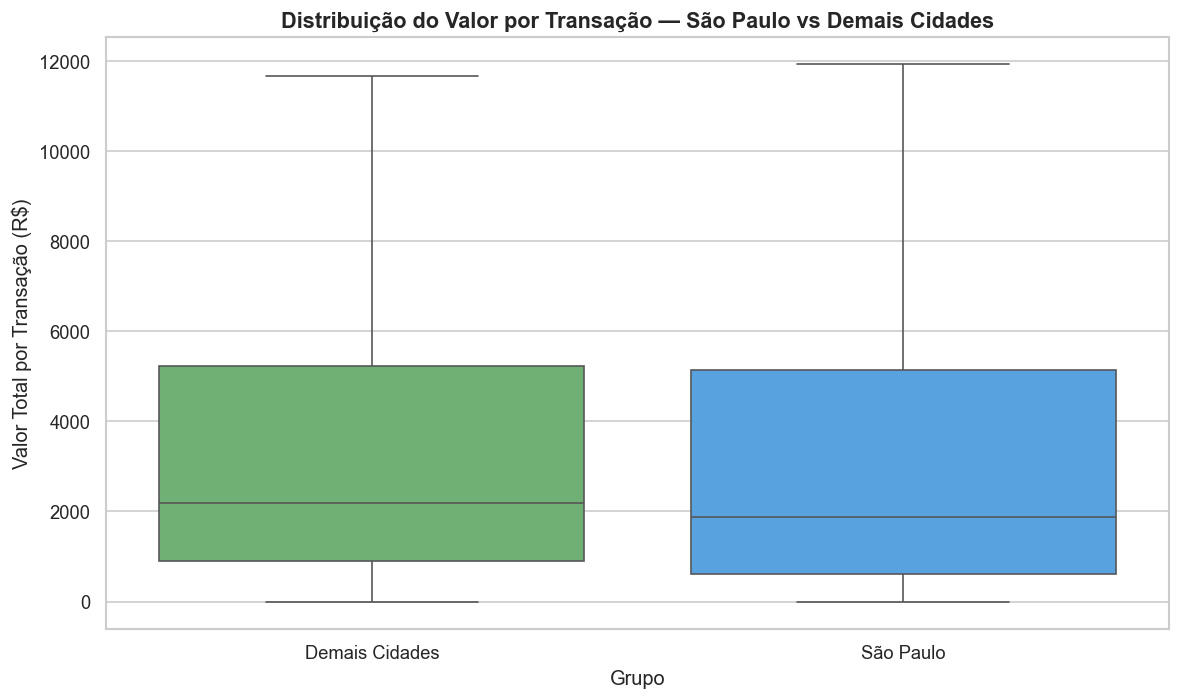

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data = df,
    x=df['Localização'].apply(lambda x: 'São Paulo' if x == 'São Paulo' else 'Demais Cidades'),
    y='Valor_Total_Corrigido',
    palette={'São Paulo': '#42A5F5', 'Demais Cidades': '#66BB6A'},
    showfliers=False,
    ax=ax
)

ax.set_title('Distribuição do Valor por Transação — São Paulo vs Demais Cidades')
ax.set_xlabel('Grupo')
ax.set_ylabel('Valor Total por Transação (R$)')

plt.tight_layout()
plt.show()

---
## 06.4 - Interpretação e Recomendação Estratégica

**Resultado do teste:**

| Estatística | Valor |
|-------------|-------|
| U-statistic | 7.787.712 |
| p-valor | 0,0001 |
| Ticket médio — São Paulo | 3.420 reais |
| Ticket médio — Demais Cidades | 3.577 reais |
| Diferença | -157 reais |
| Decisão | Rejeita H0 |

Com p-valor de 0,0001 — abaixo do nível de significância adotado (α = 0,05) — **há evidência estatística de que o ticket médio de São Paulo é significativamente menor que o das demais cidades.** A diferença de aproximadamente 157 reais é modesta em termos absolutos (~4,4%), mas consistente e não atribuível a variação aleatória.

O boxplot confirma visualmente: São Paulo apresenta mediana e Q1 ligeiramente menores que o grupo das demais cidades, com distribuição deslocada para valores mais baixos.

> **Nota sobre relevância prática:** embora estatisticamente significativa, uma diferença de 4,4% no ticket médio tem impacto  operacional limitado. O resultado é mais relevante como evidência de perfil de cliente distinto do que como gap de receita a ser corrigido imediatamente.

---

**Recomendação Estratégica**

São Paulo lidera em volume de transações mas apresenta ticket médio consistentemente menor que as demais praças. Esse padrão sugere perfis de cliente distintos entre a capital paulista e o restante do país:

- **São Paulo:** base de clientes maior, mais pulverizada e com compras de menor valor individual — perfil compatível com consumidor urbano de alta frequência e menor valor por pedido.
- **Demais cidades:** base menor mas com ticket médio superior, sugerindo compras mais concentradas em produtos de maior valor agregado.

Com base nisso, recomenda-se:
- **Estratégias de cross-sell e upsell direcionadas a São Paulo** para elevar o ticket médio sem depender apenas de volume — por exemplo, recomendação de acessórios ou produtos complementares no momento da compra.
- **Investigar quais categorias puxam o ticket para baixo em São Paulo** — se Eletrônicos de menor valor (como Fones e Acessórios) têm maior participação em SP do que nas demais cidades, isso explicaria o padrão e orientaria ações de mix de produto.
- **Replicar o mix de produtos de alto ticket das cidades líderes** (Brasília e Goiânia) em campanhas direcionadas ao mercado paulistano.

---
# 07 - Síntese Estratégica

## 07.1 - Resumo dos Testes de Hipótese

In [72]:
sintese = pd.DataFrame({
    'Hipótese': [
        'H1 — Ticket médio igual entre formas de pagamento',
        'H2 — Desconto não influencia o valor da compra',
        'H3 — Receita não varia significativamente entre os meses',
        'H4 — Ticket médio de SP igual ao das demais cidades'
    ],
    'Teste': [
        'Kruskal-Wallis',
        'Correlação de Spearman',
        'Kruskal-Wallis',
        'Mann-Whitney U'
    ],
    'p-valor': [
        '0,1084',
        '< 0,001',
        '0,9974',
        '0,0001'
    ],
    'Decisão': [
        'Não rejeita H0',
        'Rejeita H0',
        'Não rejeita H0',
        'Rejeita H0'
    ],
    'Conclusão': [
        'Sem diferença significativa',
        'Correlação negativa fraca (ρ = -0,04)',
        'Sem diferença significativa*',
        'SP tem ticket menor (−4,4%)'
    ]
})

sintese

,Hipótese,Teste,p-valor,Decisão,Conclusão
0,H1 — Ticket médio igual entre formas de pagamento,Kruskal-Wallis,"0,1084",Não rejeita H0,Sem diferença significativa
1,H2 — Desconto não influencia o valor da compra,Correlação de Spearman,"< 0,001",Rejeita H0,"Correlação negativa fraca (ρ = -0,04)"
2,H3 — Receita não varia significativamente entr...,Kruskal-Wallis,"0,9974",Não rejeita H0,Sem diferença significativa*
3,H4 — Ticket médio de SP igual ao das demais ci...,Mann-Whitney U,"0,0001",Rejeita H0,"SP tem ticket menor (−4,4%)"


*Limitação: n=3 por grupo — resultado deve ser interpretado com cautela.

## 07.2 - Recomendações Priorizadas por Impacto

As recomendações abaixo foram priorizadas considerando dois critérios:
**impacto potencial no faturamento** e **facilidade de implementação.**

---

### 🔴 Alta Prioridade

**1. Revisar a política de descontos**
A análise confirmou que os descontos atuais são indiferenciados — não estão
associados a compras de maior valor nem geram aumento de ticket. Cada desconto
concedido representa redução direta de margem sem contrapartida mensurável.

Ação recomendada: implementar **desconto progressivo por valor de compra**
(ex: 5% acima de 5.000 reais, 10% acima de 10.000 reais) para incentivar
o aumento do ticket médio de forma estruturada.

**2. Estratégia de cross-sell e upsell em São Paulo**
São Paulo lidera em volume mas tem ticket médio estatisticamente menor
que as demais cidades. Com a maior base de clientes do portfólio, um
aumento de ticket de 5-10% em SP teria impacto relevante na receita total.

Ação recomendada: implementar recomendação de produtos complementares
no momento da compra e investigar o mix de categorias específico de SP
para identificar onde o ticket está sendo puxado para baixo.

---

### 🟡 Média Prioridade

**3. Monitorar sazonalidade nos próximos anos**
O teste não confirmou sazonalidade estatisticamente significativa, mas
os padrões visuais da EDA — Fevereiro e Dezembro consistentemente mais
fracos — são recorrentes nos 3 anos disponíveis.

Ação recomendada: documentar e monitorar o comportamento mensal em 2026
e 2027. Se o padrão persistir, a evidência será suficiente para justificar
campanhas sazonais estruturadas nesses meses.

**4. Avaliar custo de transação por forma de pagamento**
O teste confirmou que o ticket médio é homogêneo entre os meios de
pagamento — não há justificativa para descontos diferenciados por meio.
No entanto, cada meio tem um custo de transação diferente para o negócio.

Ação recomendada: calcular a margem líquida por forma de pagamento
considerando os custos de processamento — Pix tende a ter custo menor
que cartões, o que pode justificar incentivos não relacionados ao ticket.

---

### 🟢 Longo Prazo

**5. Ampliar base de dados para análises mais robustas**
Duas das quatro hipóteses testadas tiveram limitações por tamanho amostral
(H3) ou por concentração de dados (H2 — único outlier de desconto 100%).
Com 5+ anos de histórico, análises de sazonalidade e correlações serão
mais confiáveis e acionáveis.

Ação recomendada: garantir a continuidade e qualidade do pipeline de dados
para que análises futuras tenham poder estatístico adequado.

---
## 07.3 - Próximos Passos

| Etapa | Conteúdo |
|-------|----------|
| Modelagem Preditiva | Previsão de receita mensal com séries temporais |
| Segmentação de Clientes | Análise RFM ou clustering por perfil de compra |
| Análise de Margem | Custo de transação por forma de pagamento |
| Dashboard Executivo | Visualização interativa em Power BI ou Streamlit |
| Monitoramento | Acompanhamento mensal de Fevereiro e Dezembro para validação de sazonalidade |